In [369]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE


In [370]:
df = pd.read_csv('credit_card_fraud.csv')

In [371]:
df.shape

(8000, 14)

In [372]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Transaction Date and Time                8000 non-null   str    
 1   Transaction Amount                       8000 non-null   float64
 2   Merchant Name                            8000 non-null   str    
 3   Merchant Category Code (MCC)             8000 non-null   int64  
 4   Transaction Location (City or ZIP Code)  8000 non-null   str    
 5   Transaction Currency                     8000 non-null   str    
 6   Card Type                                8000 non-null   str    
 7   Transaction Response Code                8000 non-null   int64  
 8   Fraud Flag or Label                      8000 non-null   int64  
 9   Previous Transactions                    5957 non-null   str    
 10  Transaction Source                       8000 non-null   st

In [373]:
df.describe()

,Transaction Amount,Merchant Category Code (MCC),Transaction Response Code,Fraud Flag or Label
count,8000.000000,8000.000000,8000.000000,8000.000000
mean,2496.356036,5484.150375,5.637500,0.498625
std,1451.221326,2608.164617,4.928147,0.500029
min,1.090000,1000.000000,0.000000,0.000000
25%,1242.580000,3230.750000,0.000000,0.000000
50%,2492.460000,5455.000000,5.000000,0.000000
75%,3739.522500,7761.000000,12.000000,1.000000
max,4996.700000,9999.000000,12.000000,1.000000


In [374]:
df.head()

,Transaction Date and Time,Transaction Amount,Merchant Name,Merchant Category Code (MCC),Transaction Location (City or ZIP Code),Transaction Currency,Card Type,Transaction Response Code,Fraud Flag or Label,Previous Transactions,Transaction Source,IP Address,Device Information,User Account Information
0,24-09-2022 13:54,285.88,"Rajagopalan, Ghose and Kant",3590,Khammam,INR,MasterCard,5,1,NaN,Online,18.106.240.6,Tablet,NaN
1,24-07-2020 11:20,1777.32,Sule PLC,7277,Vasai-Virar,EUR,American Express,12,1,NaN,Online,212.48.185.128,Mobile,jloyal
2,18-03-2023 01:05,3939.01,Badal PLC,9297,Nangloi Jat,USD,Visa,5,1,3 or more,In-Person,17.190.112.46,Mobile,NaN
3,07-01-2021 21:53,376.44,Konda-Sodhi,5686,Ramagundam,USD,Visa,5,0,2,In-Person,153.136.24.104,Tablet,NaN
4,16-12-2021 06:22,1687.33,Dua Ltd,2940,Adoni,INR,MasterCard,5,1,2,Online,196.153.28.131,Desktop,NaN


In [375]:
df.tail()

,Transaction Date and Time,Transaction Amount,Merchant Name,Merchant Category Code (MCC),Transaction Location (City or ZIP Code),Transaction Currency,Card Type,Transaction Response Code,Fraud Flag or Label,Previous Transactions,Transaction Source,IP Address,Device Information,User Account Information
7995,17-12-2020 20:36,2214.15,Manda Ltd,1236,Anantapuram,EUR,Visa,5,0,1,Online,214.34.176.247,Mobile,madhavshah
7996,04-07-2022 05:19,675.97,Bhavsar Group,3406,Guntakal,INR,Visa,0,1,3 or more,In-Person,34.237.199.33,Tablet,NaN
7997,14-08-2022 19:14,918.28,"Gole, Yohannan and Singhal",7504,Udupi,USD,MasterCard,5,1,3 or more,In-Person,220.203.140.160,Tablet,suhanavala
7998,16-05-2021 18:21,3035.31,Kakar LLC,4015,Sultan Pur Majra,EUR,American Express,0,1,1,In-Person,216.56.133.227,Tablet,sumeriyengar
7999,14-06-2023 06:12,3354.36,"Datta, Gandhi and Sha",2902,Dehradun,INR,Visa,12,0,2,In-Person,159.232.79.67,Mobile,prishaghose


In [376]:
df.isnull().sum()

Transaction Date and Time                     0
Transaction Amount                            0
Merchant Name                                 0
Merchant Category Code (MCC)                  0
Transaction Location (City or ZIP Code)       0
Transaction Currency                          0
Card Type                                     0
Transaction Response Code                     0
Fraud Flag or Label                           0
Previous Transactions                      2043
Transaction Source                            0
IP Address                                    0
Device Information                            0
User Account Information                   4010
dtype: int64

In [377]:
print(df['Transaction Date and Time'].dtype)

str


In [378]:
df['Transaction Date and Time'] = pd.to_datetime(df['Transaction Date and Time'])

C:\Users\sivap\AppData\Local\Temp\ipykernel_9728\3465828100.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Transaction Date and Time'] = pd.to_datetime(df['Transaction Date and Time'])


In [379]:
print(df['Transaction Date and Time'].dtype)

datetime64[us]


In [380]:
df['Day'] = df['Transaction Date and Time'].dt.day
df['Month'] = df['Transaction Date and Time'].dt.month
df['Year'] = df['Transaction Date and Time'].dt.year

In [381]:
df.columns

Index(['Transaction Date and Time', 'Transaction Amount', 'Merchant Name',
       'Merchant Category Code (MCC)',
       'Transaction Location (City or ZIP Code)', 'Transaction Currency',
       'Card Type', 'Transaction Response Code', 'Fraud Flag or Label',
       'Previous Transactions', 'Transaction Source', 'IP Address',
       'Device Information', 'User Account Information', 'Day', 'Month',
       'Year'],
      dtype='str')

In [382]:
df = df.drop(['Transaction Date and Time'], axis=1)

In [383]:
cols_to_drop = [
    'Merchant Name',
    'IP Address',
    'Device Information',
    'User Account Information'
]
df = df.drop(cols_to_drop, axis=1)

In [384]:
x = df.drop(['Fraud Flag or Label'], axis=1)
y = df['Fraud Flag or Label']

In [385]:
x.isnull().sum()

Transaction Amount                            0
Merchant Category Code (MCC)                  0
Transaction Location (City or ZIP Code)       0
Transaction Currency                          0
Card Type                                     0
Transaction Response Code                     0
Previous Transactions                      2043
Transaction Source                            0
Day                                           0
Month                                         0
Year                                          0
dtype: int64

In [386]:
print(x.dtypes)

Transaction Amount                         float64
Merchant Category Code (MCC)                 int64
Transaction Location (City or ZIP Code)        str
Transaction Currency                           str
Card Type                                      str
Transaction Response Code                    int64
Previous Transactions                          str
Transaction Source                             str
Day                                          int32
Month                                        int32
Year                                         int32
dtype: object


In [387]:
x = pd.get_dummies(x, drop_first=True)

In [388]:
print(x.dtypes)

Transaction Amount                 float64
Merchant Category Code (MCC)         int64
Transaction Response Code            int64
Day                                  int32
Month                                int32
                                    ...   
Card Type_MasterCard                  bool
Card Type_Visa                        bool
Previous Transactions_2               bool
Previous Transactions_3 or more       bool
Transaction Source_Online             bool
Length: 328, dtype: object


In [389]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [390]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [391]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [392]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train, y_train)

c:\Users\sivap\OneDrive\Desktop\project_4\demo\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [393]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [394]:
y_pred_lr = lr_model.predict(x_test)
y_pred_rf = rf_model.predict(x_test)

In [395]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logistic Regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.491875
              precision    recall  f1-score   support

           0       0.49      0.51      0.50       802
           1       0.49      0.47      0.48       798

    accuracy                           0.49      1600
   macro avg       0.49      0.49      0.49      1600
weighted avg       0.49      0.49      0.49      1600

Random Forest Accuracy: 0.51
              precision    recall  f1-score   support

           0       0.51      0.54      0.53       802
           1       0.51      0.48      0.49       798

    accuracy                           0.51      1600
   macro avg       0.51      0.51      0.51      1600
weighted avg       0.51      0.51      0.51      1600



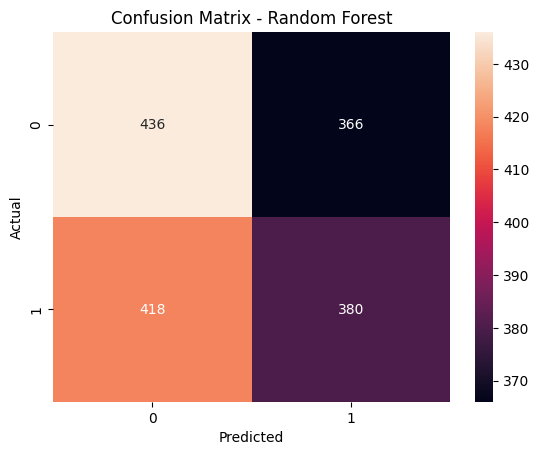

In [396]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [397]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
)

feature_importance.sort_values(ascending=False).head(10)

Transaction Amount              0.112154
Merchant Category Code (MCC)    0.111855
Day                             0.081461
Month                           0.064448
Year                            0.040335
Transaction Response Code       0.033128
Transaction Source_Online       0.019728
Transaction Currency_USD        0.017806
Transaction Currency_INR        0.017314
Card Type_MasterCard            0.016521
dtype: float64

In [398]:
print('Fraud Flag or Label' in x.columns)

False
